In [3]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)

## Exp. Design
Write some text about experimental design

## Performance Metrics

#### Learning
Start simple, lets look at trials across learning between conditions & in expert behaviour (when stim starts)

In [ ]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

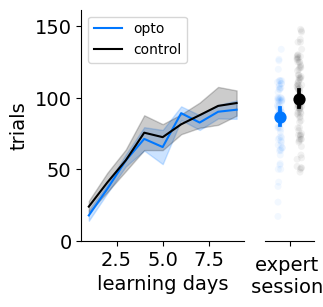

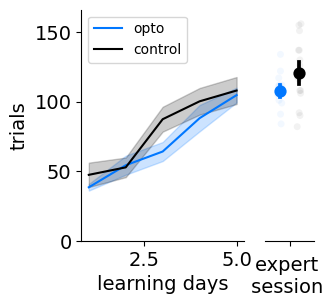

In [ ]:
reload(bl)
for maze_order in [1, 2]:
    fig, axes = plt.subplots(1, 2, figsize=(3, 3), width_ratios=[1, 0.3], sharey=True)
    bl.plot_performance_summary(learning_df, expert_df, maze_order=maze_order, print_stats=False, axes=axes)
    fig.savefig(f"../results/figures/learning_maze_order_{maze_order}.pdf")

#### Excess steps (during expert behaviour with mFC inhibition)

In [ ]:
import numpy as np
from GridMaze.analysis.behaviour import excess_steps as es

excess_steps_df = es.get_excess_steps_df(verbose=False)

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0    condition  8.001873    1   13  8.001873  12.691463  0.003472  0.493995   
1   stim_trial  2.705248    1   13  2.705248  12.269470  0.003893  0.485545   
2  Interaction  1.403784    1   13  1.403784   6.366768  0.025448  0.328747   

   eps  
0  NaN  
1  1.0  
2  NaN  


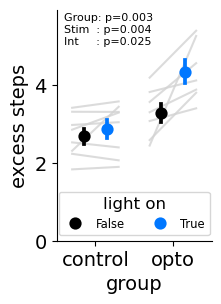

In [21]:
es.plot_random_effects_summary(
    excess_steps_df,
    stim_day_range=(4, np.inf),
    outlier_thres=250,
    min_starting_dist=None,
    print_stats=True,
)

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0    condition  8.110101    1   13  8.110101  13.304253  0.002951  0.505783   
1   stim_trial  2.974345    1   13  2.974345  19.618318  0.000680  0.601451   
2  Interaction  1.806245    1   13  1.806245  11.913714  0.004295  0.478199   

   eps  
0  NaN  
1  1.0  
2  NaN  


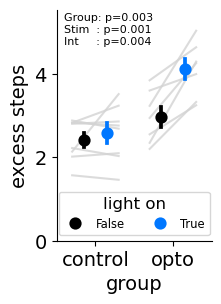

In [22]:
# focusing even more on late data
es.plot_random_effects_summary(
    excess_steps_df,
    stim_day_range=(10, np.inf),
    outlier_thres=250,
    min_starting_dist=None,
    print_stats=True,
)